In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [3]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
cagr = performance[
[
"scheme_name",
"return_3yr_pct",
"return_5yr_pct"
]
]

cagr.head()

,scheme_name,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,5.43


In [5]:
performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate


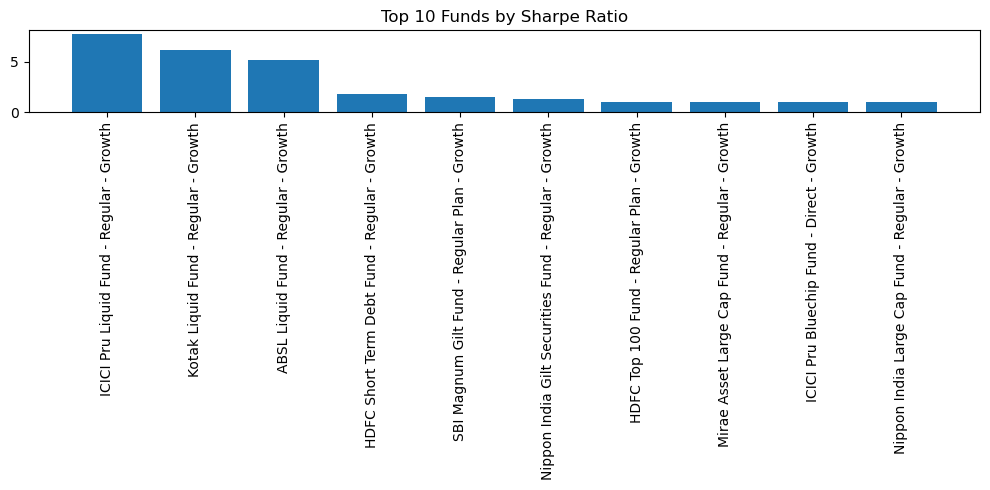

In [ ]:
import matplotlib.pyplot as plt

top_sharpe = performance.nlargest(
    10,
    "sharpe_ratio"
)

plt.figure(figsize=(10,5))

plt.bar(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()
plt.savefig(
    "../reports/sharpe_ratio_top10.png",
    bbox_inches="tight"
)
plt.show()

Funds with higher Sharpe Ratios provide better risk-adjusted returns and are generally preferred by investors.

In [7]:
performance.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate


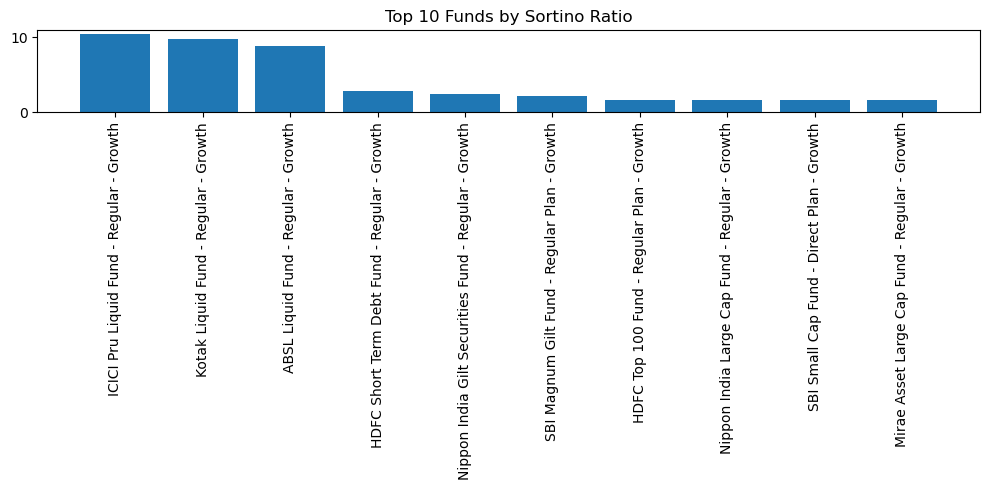

In [8]:
top_sortino = performance.nlargest(
    10,
    "sortino_ratio"
)

plt.figure(figsize=(10,5))

plt.bar(
    top_sortino["scheme_name"],
    top_sortino["sortino_ratio"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

Funds with higher Sortino Ratios generate better returns while minimizing downside risk.

In [9]:
performance[
[
"scheme_name",
"alpha",
"beta"
]
].head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [10]:
performance.nlargest(
    10,
    "alpha"
)[
[
"scheme_name",
"alpha"
]
]

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
16,Nippon India Large Cap Fund - Direct - Growth,1.70


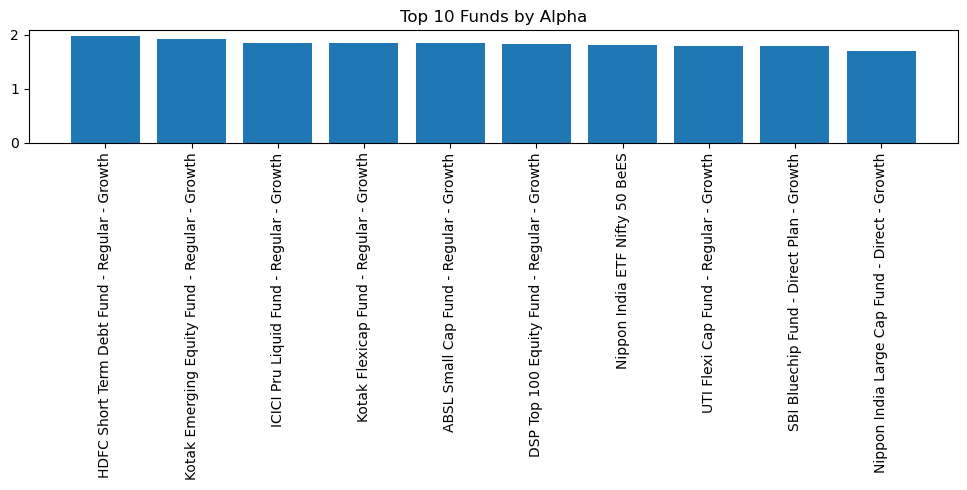

In [11]:
top_alpha = performance.nlargest(
    10,
    "alpha"
)

plt.figure(figsize=(10,5))

plt.bar(
    top_alpha["scheme_name"],
    top_alpha["alpha"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.show()

Positive Alpha indicates that a fund has outperformed its benchmark after adjusting for risk.

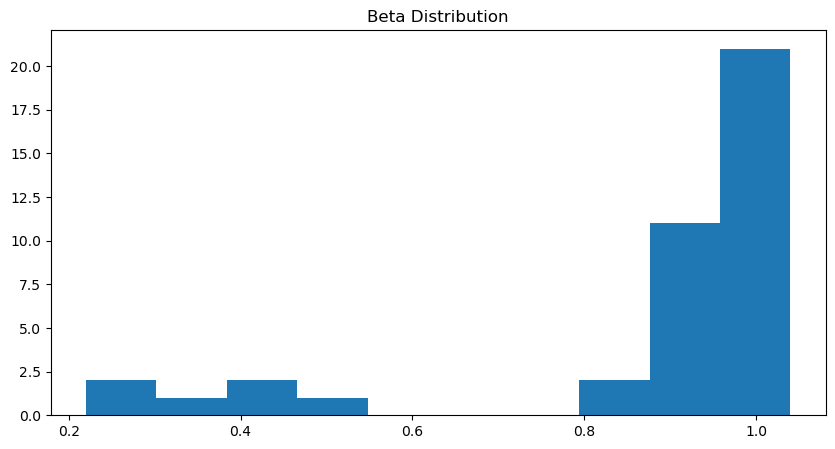

In [12]:
plt.figure(figsize=(10,5))

plt.hist(
    performance["beta"],
    bins=10
)

plt.title(
    "Beta Distribution"
)

plt.show()

Most funds have Beta values close to 1, indicating performance similar to the market.

In [13]:
performance[
[
"scheme_name",
"max_drawdown_pct"
]
].head()

,scheme_name,max_drawdown_pct
0,SBI Bluechip Fund - Regular Plan - Growth,-21.70
1,SBI Bluechip Fund - Direct Plan - Growth,-24.43
2,SBI Small Cap Fund - Regular Plan - Growth,-13.35
3,SBI Small Cap Fund - Direct Plan - Growth,-24.78
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-2.30


In [14]:
worst_drawdown = performance.nlargest(
    10,
    "max_drawdown_pct"
)

worst_drawdown[
[
"scheme_name",
"max_drawdown_pct"
]
]

,scheme_name,max_drawdown_pct
19,Nippon India Gilt Securities Fund - Regular - ...,-2.23
4,SBI Magnum Gilt Fund - Regular Plan - Growth,-2.30
14,ICICI Pru Liquid Fund - Regular - Growth,-2.62
30,ABSL Liquid Fund - Regular - Growth,-3.66
23,Kotak Liquid Fund - Regular - Growth,-3.81
9,HDFC Short Term Debt Fund - Regular - Growth,-6.01
33,UTI Flexi Cap Fund - Regular - Growth,-12.14
2,SBI Small Cap Fund - Regular Plan - Growth,-13.35
32,UTI Mid Cap Fund - Regular - Growth,-13.43
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-13.67


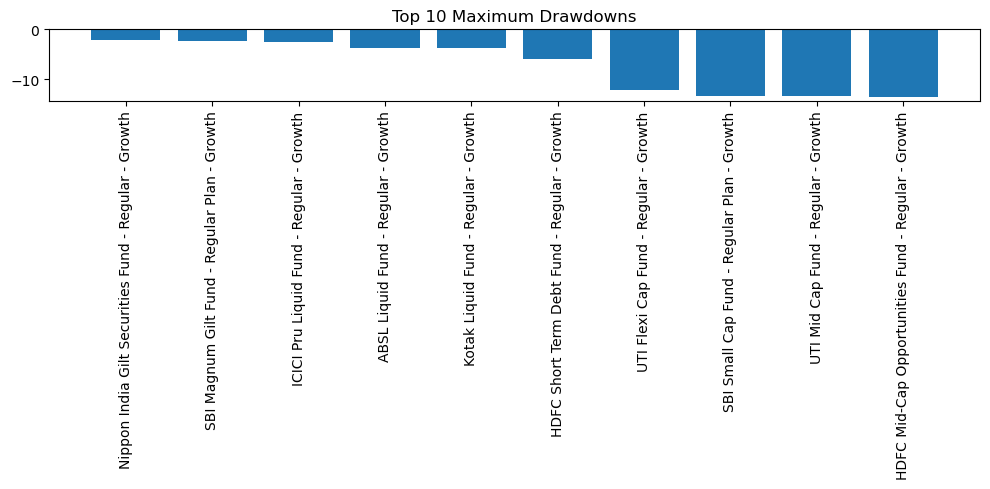

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    worst_drawdown["scheme_name"],
    worst_drawdown["max_drawdown_pct"]
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Maximum Drawdowns"
)

plt.tight_layout()

plt.show()

Funds with higher maximum drawdowns experienced larger losses during market downturns.

In [16]:
performance["score"] = (
    performance["return_3yr_pct"] * 0.30 +
    performance["sharpe_ratio"] * 0.25 +
    performance["alpha"] * 0.20 -
    performance["expense_ratio_pct"] * 0.15 -
    performance["max_drawdown_pct"] * 0.10
)

In [17]:
fund_scorecard = performance[
[
"scheme_name",
"score"
]
].sort_values(
    "score",
    ascending=False
)

fund_scorecard.head(10)

,scheme_name,score
3,SBI Small Cap Fund - Direct Plan - Growth,9.7705
29,ABSL Small Cap Fund - Regular - Growth,9.4385
17,Nippon India Small Cap Fund - Regular - Growth,9.2650
2,SBI Small Cap Fund - Regular Plan - Growth,8.6185
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,8.0720
26,Axis Midcap Fund - Regular - Growth,8.0690
21,Kotak Emerging Equity Fund - Regular - Growth,8.0490
38,DSP Midcap Fund - Regular - Growth,8.0345
35,Mirae Asset Emerging Bluechip Fund - Regular -...,8.0225
27,Axis Small Cap Fund - Regular - Growth,7.8440


In [18]:
fund_scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("✅ fund_scorecard.csv created")

✅ fund_scorecard.csv created


In [19]:
alpha_beta = performance[
[
"scheme_name",
"alpha",
"beta"
]
]

alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("✅ alpha_beta.csv created")

✅ alpha_beta.csv created


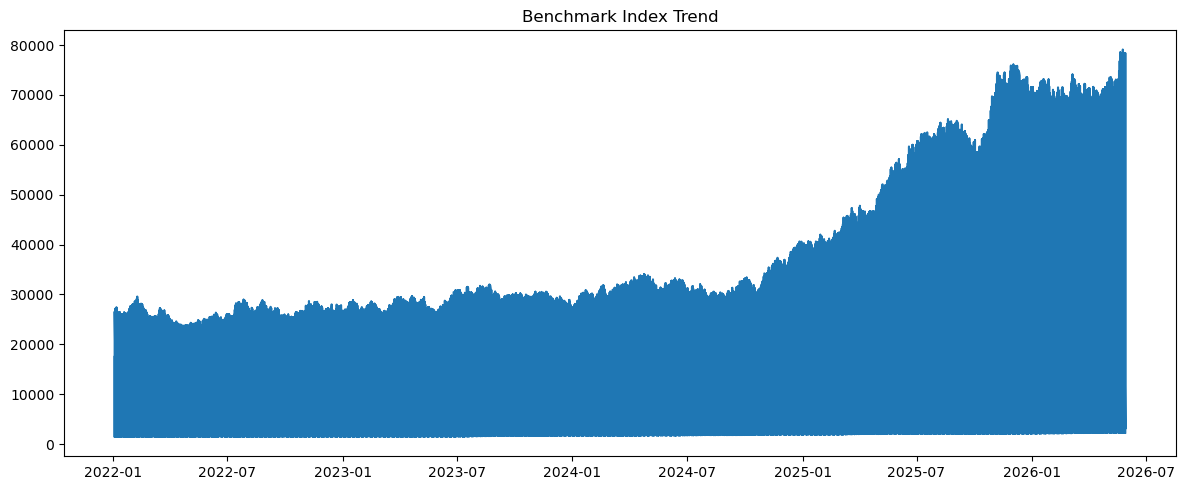

In [22]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

plt.figure(figsize=(12,5))

plt.plot(
    benchmark["date"],
    benchmark["close_value"]
)

plt.title(
    "Benchmark Index Trend"
)

plt.tight_layout()
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)
plt.show()

Benchmark indices showed a positive long-term trend despite periodic market corrections.

In [23]:
import os

print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_counts_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benchmark_indices_clean.csv', 'alpha_beta.csv', 'fund_scorecard.csv']
